In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded ✓")
print(f"NumPy version: {np.__version__}")

Libraries loaded ✓
NumPy version: 2.4.3


In [ ]:
def bs_d1_d2(S, K, T, r, sigma, q=0.0):
    """
    Compute d1 and d2 — the core arguments of the Black-Scholes formula.
    These appear in both pricing and Greeks, so we factor them out.

    Returns
    -------
    d1, d2 : float or np.ndarray
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    """
    Black-Scholes price for a European option.

    Parameters
    ----------
    S           : float or array — spot price
    K           : float or array — strike price
    T           : float or array — time to expiry (years)
    r           : float — risk-free rate (annualized, continuously compounded)
    sigma       : float or array — implied volatility (annualized)
    q           : float — continuous dividend yield (default 0)
    option_type : str — "call" or "put"

    Returns
    -------
    price : float or np.ndarray
    """
    S, K, T, sigma = map(np.asarray, [S, K, T, sigma])

    # Edge case: expired option — return intrinsic value
    if np.all(T <= 0):
        if option_type == "call":
            return np.maximum(S - K, 0.0)
        else:
            return np.maximum(K - S, 0.0)

    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)

    if option_type == "call":
        price = (S * np.exp(-q * T) * norm.cdf(d1)
                 - K * np.exp(-r * T) * norm.cdf(d2))
    elif option_type == "put":
        price = (K * np.exp(-r * T) * norm.cdf(-d2)
                 - S * np.exp(-q * T) * norm.cdf(-d1))
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price


# Quick smoke test
C = bs_price(S=100, K=100, T=1.0, r=0.05, sigma=0.2, option_type="call")
P = bs_price(S=100, K=100, T=1.0, r=0.05, sigma=0.2, option_type="put")
print(f"ATM Call price: {C:.4f}")
print(f"ATM Put  price: {P:.4f}")

ATM Call price: 10.4506
ATM Put  price: 5.5735


In [ ]:
def check_put_call_parity(S, K, T, r, sigma, q=0.0, tol=1e-8):
    """
    Verify put-call parity holds for the BS formula.
    Returns True if parity holds within tolerance.
    """
    C = bs_price(S, K, T, r, sigma, q, option_type="call")
    P = bs_price(S, K, T, r, sigma, q, option_type="put")

    lhs = C - P                                 
    rhs = S * np.exp(-q * T) - K * np.exp(-r * T) 

    diff = abs(lhs - rhs)
    passed = diff < tol

    print(f"C - P          = {lhs:.8f}")
    print(f"S·e^(-qT) - Ke^(-rT) = {rhs:.8f}")
    print(f"Difference     = {diff:.2e}")
    print(f"Parity holds: {'✓ YES' if passed else '✗ NO'}")
    return passed

print("\n--- Put-Call Parity Check ---")
check_put_call_parity(S=100, K=105, T=0.5, r=0.05, sigma=0.25, q=0.02)


--- Put-Call Parity Check ---
C - P          = -3.40255739
S·e^(-qT) - Ke^(-rT) = -3.40255739
Difference     = 7.11e-15
Parity holds: ✓ YES


np.True_

In [ ]:
def bs_greeks(S, K, T, r, sigma, q=0.0, option_type="call"):
    """
    Compute all 5 Greeks for a European option under Black-Scholes.

    Returns
    -------
    dict with keys: delta, gamma, vega, theta, rho
    Notes:
      - theta is per calendar day (divided by 365)
      - vega is per 1% change in vol (divided by 100)
      - rho is per 1% change in interest rate (divided by 100)
    """
    S, K, T = map(float, [S, K, T])

    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)

    phi_d1 = norm.pdf(d1)       
    N_d1   = norm.cdf(d1)
    N_d2   = norm.cdf(d2)
    N_md1  = norm.cdf(-d1)
    N_md2  = norm.cdf(-d2)

    sqrt_T  = np.sqrt(T)
    e_qT    = np.exp(-q * T)
    e_rT    = np.exp(-r * T)

    #Delta
    if option_type == "call":
        delta = e_qT * N_d1
    else:
        delta = e_qT * (N_d1 - 1)      

    #Gamma
    gamma = (phi_d1 * e_qT) / (S * sigma * sqrt_T)

    #Vega
    vega = S * e_qT * phi_d1 * sqrt_T / 100

    # Theta (per calendar day)
    # Theta has two components:
    #   - time value decay from volatility
    #   - carry cost of the position (r and q terms)
    common_theta = -(S * e_qT * phi_d1 * sigma) / (2 * sqrt_T)

    if option_type == "call":
        theta = (common_theta
                 - r * K * e_rT * N_d2
                 + q * S * e_qT * N_d1) / 365
    else:
        theta = (common_theta
                 + r * K * e_rT * N_md2
                 - q * S * e_qT * N_md1) / 365

    # Rho
    if option_type == "call":
        rho = K * T * e_rT * N_d2 / 100
    else:
        rho = -K * T * e_rT * N_md2 / 100

    return {
        "delta": delta,
        "gamma": gamma,
        "vega":  vega,
        "theta": theta,
        "rho":   rho,
    }


# Print Greeks for our ATM example
print("\n--- Greeks for ATM Call (S=100, K=100, T=1, r=5%, σ=20%) ---")
g = bs_greeks(S=100, K=100, T=1.0, r=0.05, sigma=0.2, option_type="call")
for name, val in g.items():
    print(f"  {name.capitalize():6s}: {val:.6f}")

print("\n--- Greeks for ATM Put ---")
g_put = bs_greeks(S=100, K=100, T=1.0, r=0.05, sigma=0.2, option_type="put")
for name, val in g_put.items():
    print(f"  {name.capitalize():6s}: {val:.6f}")

# KEY RELATIONSHIPS to verify:
# 1. Call delta - Put delta = e^{-qT}  (put-call parity for deltas)
# 2. Call rho - Put rho = -K·T·e^{-rT} / 100
# 3. Gamma and Vega are equal for calls and puts
print(f"\nDelta (call) - Delta (put) = {g['delta'] - g_put['delta']:.6f}")
print(f"e^(-qT)                    = {np.exp(0):.6f}  ← should match")


--- Greeks for ATM Call (S=100, K=100, T=1, r=5%, σ=20%) ---
  Delta : 0.636831
  Gamma : 0.018762
  Vega  : 0.375240
  Theta : -0.017573
  Rho   : 0.532325

--- Greeks for ATM Put ---
  Delta : -0.363169
  Gamma : 0.018762
  Vega  : 0.375240
  Theta : -0.004542
  Rho   : -0.418905

Delta (call) - Delta (put) = 1.000000
e^(-qT)                    = 1.000000  ← should match


In [ ]:
def implied_vol(market_price, S, K, T, r, q=0.0, option_type="call",
                method="newton", tol=1e-6, max_iter=100):
    """
    Compute implied volatility from a market option price.

    Parameters
    ----------
    market_price : float — observed market price of the option
    method       : "newton" (fast, needs vega) or "brent" (robust fallback)

    Returns
    -------
    iv : float — implied volatility (annualized)
         Returns np.nan if no solution found
    """
    # Basic arbitrage bounds check
    intrinsic = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0) if option_type == "call" \
                else max(K * np.exp(-r * T) - S * np.exp(-q * T), 0)

    if market_price < intrinsic - tol:
        return np.nan   
    if market_price <= 0:
        return np.nan

    if method == "newton":
        # Initial guess: Brenner-Subrahmanyam approximation
        # Good starting point for near-ATM options
        sigma = np.sqrt(2 * np.abs(np.log(S / K) + (r - q) * T) / T)
        sigma = max(sigma, 0.01)  # floor at 1%

        for i in range(max_iter):
            price = bs_price(S, K, T, r, sigma, q, option_type)
            vega  = bs_greeks(S, K, T, r, sigma, q, option_type)["vega"] * 100

            if abs(vega) < 1e-10:
                break  # vega ~ 0 means we're in extreme territory, fall back

            diff  = price - market_price
            sigma -= diff / vega

            sigma = max(sigma, 1e-6) 

            if abs(diff) < tol:
                return sigma

    # Brent's method: slower but guaranteed to converge
    try:
        iv = brentq(
            lambda sig: bs_price(S, K, T, r, sig, q, option_type) - market_price,
            a=1e-4, b=10.0, xtol=tol, maxiter=max_iter
        )
        return iv
    except ValueError:
        return np.nan


# Test: recover σ=0.25 from the BS price it generates
test_price = bs_price(S=100, K=110, T=0.5, r=0.05, sigma=0.25, option_type="call")
recovered_iv = implied_vol(test_price, S=100, K=110, T=0.5, r=0.05, option_type="call")
print(f"\nOriginal σ    = 0.2500")
print(f"Recovered IV  = {recovered_iv:.4f}")
print(f"Round-trip error: {abs(recovered_iv - 0.25):.2e}  ← should be ~1e-7")


Original σ    = 0.2500
Recovered IV  = 0.2500
Round-trip error: 2.78e-16  ← should be ~1e-7


In [ ]:
S     = 100.0
T     = 1.0
r     = 0.05
sigma = 0.20
q     = 0.0

# Array of 200 strikes from 70 to 140 (moneyness range 0.7x to 1.4x)
K_grid = np.linspace(70, 140, 200)

# Vectorized : one call, prices all 200 strikes simultaneously
call_prices = bs_price(S, K_grid, T, r, sigma, q, option_type="call")
put_prices  = bs_price(S, K_grid, T, r, sigma, q, option_type="put")

# Vectorized Greeks along the strike grid
# (pass sigma as a scalar — BS applies same vol to all strikes)
d1_vec, d2_vec = bs_d1_d2(S, K_grid, T, r, sigma, q)
delta_call = np.exp(-q * T) * norm.cdf(d1_vec)
gamma_all  = norm.pdf(d1_vec) * np.exp(-q * T) / (S * sigma * np.sqrt(T))

print(f"\nPriced {len(K_grid)} strikes in one vectorized call ✓")
print(f"Call price range: [{call_prices.min():.2f}, {call_prices.max():.2f}]")
print(f"Put  price range: [{put_prices.min():.2f},  {put_prices.max():.2f}]")


Priced 200 strikes in one vectorized call ✓
Call price range: [0.78, 33.54]
Put  price range: [0.13,  33.96]


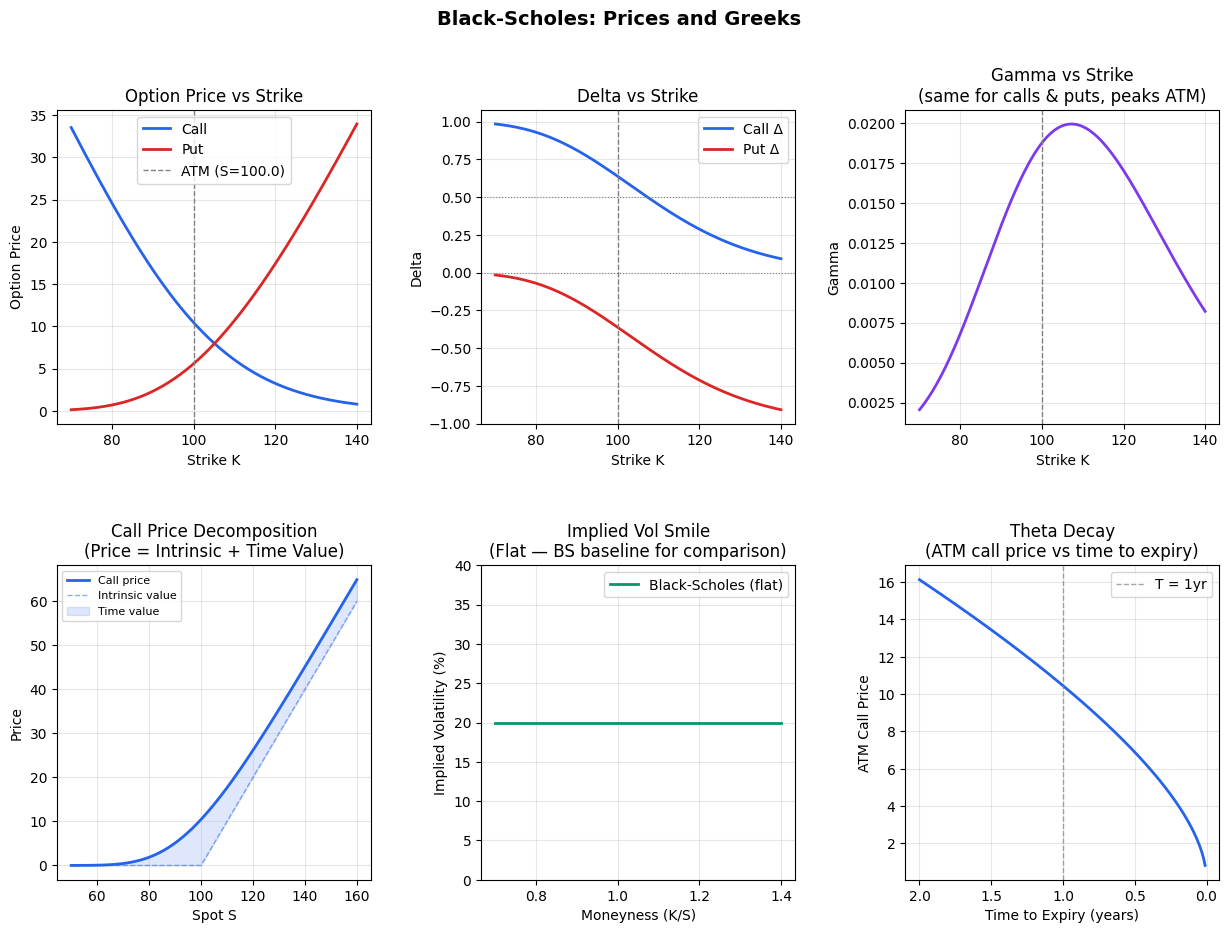

Plots saved ✓


In [7]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Black-Scholes: Prices and Greeks", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Option prices vs strike
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(K_grid, call_prices, label="Call", color="#2563EB", lw=2)
ax1.plot(K_grid, put_prices,  label="Put",  color="#DC2626", lw=2)
ax1.axvline(S, color="gray", ls="--", lw=1, label=f"ATM (S={S})")
ax1.set_xlabel("Strike K")
ax1.set_ylabel("Option Price")
ax1.set_title("Option Price vs Strike")
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Delta vs strike
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(K_grid, delta_call, color="#2563EB", lw=2, label="Call Δ")
ax2.plot(K_grid, delta_call - 1, color="#DC2626", lw=2, label="Put Δ")  # put-call parity
ax2.axvline(S, color="gray", ls="--", lw=1)
ax2.axhline(0, color="gray", ls=":", lw=0.8)
ax2.axhline(0.5, color="gray", ls=":", lw=0.8)
ax2.set_xlabel("Strike K")
ax2.set_ylabel("Delta")
ax2.set_title("Delta vs Strike")
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Gamma vs strike
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(K_grid, gamma_all, color="#7C3AED", lw=2)
ax3.axvline(S, color="gray", ls="--", lw=1)
ax3.set_xlabel("Strike K")
ax3.set_ylabel("Gamma")
ax3.set_title("Gamma vs Strike\n(same for calls & puts, peaks ATM)")
ax3.grid(alpha=0.3)

# 4. Price vs spot (for a fixed strike — shows the "hockey stick" payoff)
S_range = np.linspace(50, 160, 300)
call_vs_spot = bs_price(S_range, K=100, T=1.0, r=0.05, sigma=0.20, option_type="call")
put_vs_spot  = bs_price(S_range, K=100, T=1.0, r=0.05, sigma=0.20, option_type="put")
intrinsic_c  = np.maximum(S_range - 100, 0)
intrinsic_p  = np.maximum(100 - S_range, 0)

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(S_range, call_vs_spot, color="#2563EB", lw=2, label="Call price")
ax4.plot(S_range, intrinsic_c,  color="#2563EB", lw=1, ls="--", alpha=0.5, label="Intrinsic value")
ax4.fill_between(S_range, call_vs_spot, intrinsic_c, alpha=0.15, color="#2563EB", label="Time value")
ax4.set_xlabel("Spot S")
ax4.set_ylabel("Price")
ax4.set_title("Call Price Decomposition\n(Price = Intrinsic + Time Value)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# 5. IV surface (flat! — BS has constant vol, this is the baseline)
# We'll overlay Heston/Merton smiles on this in Phase 4
iv_flat = np.full_like(K_grid, sigma)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(K_grid / S, iv_flat * 100, color="#059669", lw=2, label="Black-Scholes (flat)")
ax5.set_xlabel("Moneyness (K/S)")
ax5.set_ylabel("Implied Volatility (%)")
ax5.set_title("Implied Vol Smile\n(Flat — BS baseline for comparison)")
ax5.set_ylim(0, 40)
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Theta decay curve — how time value erodes
T_range = np.linspace(0.01, 2.0, 200)
call_prices_T = bs_price(S=100, K=100, T=T_range, r=0.05, sigma=0.20, option_type="call")

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(T_range, call_prices_T, color="#2563EB", lw=2)
ax6.axvline(1.0, color="gray", ls="--", lw=1, alpha=0.7, label="T = 1yr")
ax6.set_xlabel("Time to Expiry (years)")
ax6.set_ylabel("ATM Call Price")
ax6.set_title("Theta Decay\n(ATM call price vs time to expiry)")
ax6.legend()
ax6.grid(alpha=0.3)
ax6.invert_xaxis()   # time flows right to left (from far expiry to 0)

plt.savefig("../outputs/phase1_bs_greeks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved ✓")

In [8]:
print("\n" + "="*60)
print("VALIDATION SUITE")
print("="*60)

passed = 0
failed = 0

def run_test(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  ✓ {name}")
        passed += 1
    else:
        print(f"  ✗ {name}  ← FAILED  {detail}")
        failed += 1

# --- Test 1: Put-Call Parity (multiple parameter combos) ---
print("\n[1] Put-Call Parity")
for S, K, T, r, sigma, q in [
    (100, 100, 1.0, 0.05, 0.20, 0.0),
    (100, 90,  0.5, 0.03, 0.30, 0.02),
    (50,  60,  2.0, 0.08, 0.15, 0.0),
    (200, 150, 0.25, 0.06, 0.35, 0.03),
]:
    C = bs_price(S, K, T, r, sigma, q, "call")
    P = bs_price(S, K, T, r, sigma, q, "put")
    parity = C - P - (S * np.exp(-q * T) - K * np.exp(-r * T))
    run_test(f"S={S}, K={K}, T={T}", abs(parity) < 1e-8, f"residual={parity:.2e}")

# --- Test 2: Delta bounds ---
print("\n[2] Delta bounds (call ∈ [0,1], put ∈ [-1,0])")
for K in [70, 85, 100, 115, 130]:
    g = bs_greeks(100, K, 1.0, 0.05, 0.20, option_type="call")
    run_test(f"Call delta K={K}", 0 <= g["delta"] <= 1)
for K in [70, 85, 100, 115, 130]:
    g = bs_greeks(100, K, 1.0, 0.05, 0.20, option_type="put")
    run_test(f"Put delta K={K}", -1 <= g["delta"] <= 0)

# --- Test 3: Delta adds to e^{-qT} (put-call parity for deltas) ---
print("\n[3] Delta_call - Delta_put = e^{-qT}")
for q in [0.0, 0.02, 0.05]:
    gc = bs_greeks(100, 100, 1.0, 0.05, 0.20, q=q, option_type="call")
    gp = bs_greeks(100, 100, 1.0, 0.05, 0.20, q=q, option_type="put")
    run_test(f"q={q}", abs(gc["delta"] - gp["delta"] - np.exp(-q)) < 1e-10)

# --- Test 4: Gamma and Vega same for calls and puts ---
print("\n[4] Gamma and Vega identical for calls and puts")
gc = bs_greeks(100, 110, 1.0, 0.05, 0.20, option_type="call")
gp = bs_greeks(100, 110, 1.0, 0.05, 0.20, option_type="put")
run_test("Gamma", abs(gc["gamma"] - gp["gamma"]) < 1e-10)
run_test("Vega",  abs(gc["vega"]  - gp["vega"])  < 1e-10)

# --- Test 5: Price > 0 for T > 0 and sigma > 0 ---
print("\n[5] Positive prices for various parameters")
for S, K, T in [(100, 100, 1), (100, 150, 0.1), (100, 50, 0.1)]:
    C = bs_price(S, K, T, 0.05, 0.20, option_type="call")
    P = bs_price(S, K, T, 0.05, 0.20, option_type="put")
    run_test(f"Call>0 S={S},K={K}", C > 0)
    run_test(f"Put>0  S={S},K={K}", P > 0)

# --- Test 6: Implied vol round-trip ---
print("\n[6] IV round-trip (recover σ from BS price)")
for sigma_true in [0.10, 0.20, 0.35, 0.50]:
    price = bs_price(100, 100, 1.0, 0.05, sigma_true, option_type="call")
    iv    = implied_vol(price, 100, 100, 1.0, 0.05, option_type="call")
    run_test(f"σ={sigma_true}", abs(iv - sigma_true) < 1e-5)

# --- Test 7: Boundary conditions ---
print("\n[7] Boundary conditions")
# Deep ITM call ≈ S·e^{-qT} - K·e^{-rT} (intrinsic)
deep_itm = bs_price(200, 100, 1.0, 0.05, 0.20, option_type="call")
run_test("Deep ITM call > intrinsic", deep_itm > max(200 - 100 * np.exp(-0.05), 0))
# Deep OTM call ≈ 0
deep_otm = bs_price(50, 200, 1.0, 0.05, 0.20, option_type="call")
run_test("Deep OTM call < 0.01", deep_otm < 0.01)

print(f"\n{'='*60}")
print(f"Results: {passed} passed, {failed} failed")
print(f"{'='*60}")
if failed == 0:
    print("All tests passed ✓  — Phase 1 implementation is correct.")
    print("Ready to build Binomial Tree in Phase 2.")


VALIDATION SUITE

[1] Put-Call Parity
  ✓ S=100, K=100, T=1.0
  ✓ S=100, K=90, T=0.5
  ✓ S=50, K=60, T=2.0
  ✓ S=200, K=150, T=0.25

[2] Delta bounds (call ∈ [0,1], put ∈ [-1,0])
  ✓ Call delta K=70
  ✓ Call delta K=85
  ✓ Call delta K=100
  ✓ Call delta K=115
  ✓ Call delta K=130
  ✓ Put delta K=70
  ✓ Put delta K=85
  ✓ Put delta K=100
  ✓ Put delta K=115
  ✓ Put delta K=130

[3] Delta_call - Delta_put = e^{-qT}
  ✓ q=0.0
  ✓ q=0.02
  ✓ q=0.05

[4] Gamma and Vega identical for calls and puts
  ✓ Gamma
  ✓ Vega

[5] Positive prices for various parameters
  ✓ Call>0 S=100,K=100
  ✓ Put>0  S=100,K=100
  ✓ Call>0 S=100,K=150
  ✓ Put>0  S=100,K=150
  ✓ Call>0 S=100,K=50
  ✓ Put>0  S=100,K=50

[6] IV round-trip (recover σ from BS price)
  ✓ σ=0.1
  ✓ σ=0.2
  ✓ σ=0.35
  ✓ σ=0.5

[7] Boundary conditions
  ✓ Deep ITM call > intrinsic
  ✓ Deep OTM call < 0.01

Results: 31 passed, 0 failed
All tests passed ✓  — Phase 1 implementation is correct.
Ready to build Binomial Tree in Phase 2.
